# Day 20 Tutorial：正则化与内部早停

> **课程附带教程，不是学习者运行记录。** ESOL logS 结果不能替代下游任务实验。

## Goal

在运行前固定两个 MLP 候选，比较训练/外部验证 RMSE、迭代数、训练损失，以及早停模型内部留出集上的 R² 历史。


## Setup

使用与 Day 19 相同的 ESOL scaffold train/valid。两个候选共享 32 单元隐藏层、学习率、300 次上限与随机种子；早停候选使用 10 轮耐心。

**实现边界：** sklearn Pipeline 会先在全部 `X_train` 上拟合插补器和缩放器，之后 `MLPRegressor` 才从变换后的矩阵中切内部早停集。外部 valid/test 没有进入训练，但内部早停集的预处理并未严格隔离；这里的内部 R² 只作教学诊断，不作嵌套验证证据。


In [1]:
from pathlib import Path
import contextlib
import io

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.warning")

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    import deepchem as dc

import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
np.random.seed(SEED)

def find_repo_root(start=Path.cwd().resolve()):
    for candidate in (start, *start.parents):
        if (candidate / "data" / "public" / "esol.md").exists():
            return candidate
    raise RuntimeError("请从 ML-Learning 仓库内运行本教程。")

REPO_ROOT = find_repo_root()
CACHE_DIR = REPO_ROOT / ".cache" / "deepchem"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

featurizer = dc.feat.CircularFingerprint(size=1024, radius=2)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    tasks, datasets, transformers = dc.molnet.load_delaney(
        featurizer=featurizer,
        splitter="scaffold",
        transformers=[],
        reload=True,
        data_dir=str(CACHE_DIR),
        save_dir=str(CACHE_DIR),
    )

train_dataset, valid_dataset, _sealed_test_dataset = datasets
X_train = np.asarray(train_dataset.X)
y_train = np.asarray(train_dataset.y).reshape(-1)
X_valid = np.asarray(valid_dataset.X)
y_valid = np.asarray(valid_dataset.y).reshape(-1)
train_ids = np.asarray(train_dataset.ids).astype(str)
valid_ids = np.asarray(valid_dataset.ids).astype(str)

assert transformers == []
assert X_train.shape == (902, 1024) and y_train.shape == (902,)
assert X_valid.shape == (113, 1024) and y_valid.shape == (113,)
print("Task:", tasks[0])
print("Train / valid:", X_train.shape, X_valid.shape)
print("测试集对象保持封存，本教程不创建测试预测。")


Task: measured log solubility in mols per litre
Train / valid: (902, 1024) (113, 1024)
测试集对象保持封存，本教程不创建测试预测。


In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

candidate_specs = {
    "weak_regularization_no_early_stop": {
        "alpha": 0.00001,
        "early_stopping": False,
    },
    "regularized_early_stop": {
        "alpha": 0.001,
        "early_stopping": True,
    },
}
display(pd.DataFrame(candidate_specs).T)


,alpha,early_stopping
weak_regularization_no_early_stop,0.00001,False
regularized_early_stop,0.001,True


## Steps

### 1. 独立创建并拟合候选

每个候选是新 Pipeline。外部验证不传入 `fit()`；`validation_scores_` 只使用 `X_train` 内部留出标签，并且对回归器表示 R²，不是 RMSE。注意其特征已经经过在全部 `X_train` 上拟合的预处理。


In [3]:
fitted = {}
records = []
for name, spec in candidate_specs.items():
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(32,),
            alpha=spec["alpha"],
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=spec["early_stopping"],
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=SEED,
        ),
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        model.fit(X_train, y_train)

    trained = model.named_steps["mlpregressor"]
    internal_r2_history = getattr(trained, "validation_scores_", None)
    fitted[name] = model
    records.append({
        "candidate": name,
        "train_rmse": root_mean_squared_error(
            y_train, model.predict(X_train)
        ),
        "valid_rmse": root_mean_squared_error(
            y_valid, model.predict(X_valid)
        ),
        "n_iter": trained.n_iter_,
        "loss_points": len(trained.loss_curve_),
        "internal_r2_points": (
            len(internal_r2_history)
            if internal_r2_history is not None else None
        ),
        "best_internal_r2": getattr(
            trained, "best_validation_score_", None
        ),
        "convergence_warning": any(
            issubclass(item.category, ConvergenceWarning)
            for item in caught
        ),
    })

comparison = pd.DataFrame(records)
display(comparison.round(4))


,candidate,train_rmse,valid_rmse,n_iter,loss_points,internal_r2_points,best_internal_r2,convergence_warning
0,weak_regularization_no_early_stop,0.3100,3.0669,116,116,NaN,NaN,False
1,regularized_early_stop,0.6478,3.0735,74,74,74.0,0.311,False


### 2. 分开查看训练损失与内部 R²

`loss_curve_` 是内部训练损失；`validation_scores_` 是早停留出集的逐轮 R²。两者都不是外部验证 RMSE。


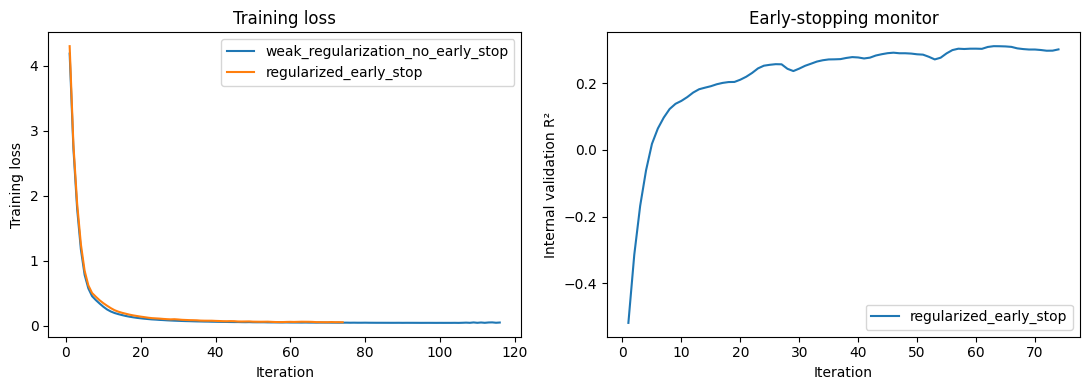

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, model in fitted.items():
    trained = model.named_steps["mlpregressor"]
    axes[0].plot(
        np.arange(1, len(trained.loss_curve_) + 1),
        trained.loss_curve_,
        label=name,
    )
    internal_r2 = getattr(trained, "validation_scores_", None)
    if internal_r2 is not None:
        axes[1].plot(
            np.arange(1, len(internal_r2) + 1),
            internal_r2,
            label=name,
        )
axes[0].set(
    xlabel="Iteration",
    ylabel="Training loss",
    title="Training loss",
)
axes[1].set(
    xlabel="Iteration",
    ylabel="Internal validation R²",
    title="Early-stopping monitor",
)
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()


## Checks

验证每个候选只产生一行、损失长度与迭代数一致；不开早停时内部 R² 属性保持“不适用”，而不是伪装成 0。


In [5]:
assert comparison["candidate"].is_unique
assert len(comparison) == len(candidate_specs)
for name, model in fitted.items():
    trained = model.named_steps["mlpregressor"]
    assert len(trained.loss_curve_) == trained.n_iter_
no_es = fitted[
    "weak_regularization_no_early_stop"
].named_steps["mlpregressor"]
with_es = fitted[
    "regularized_early_stop"
].named_steps["mlpregressor"]
assert getattr(no_es, "validation_scores_", None) is None
assert len(with_es.validation_scores_) == with_es.n_iter_
assert np.isclose(
    max(with_es.validation_scores_),
    with_es.best_validation_score_,
)
assert np.isfinite(comparison[["train_rmse", "valid_rmse"]]).all().all()
print("Checks passed. 内部监控量是 R²；外部 valid 只用于最终比较。")
print("Known limitation: preprocessing saw all X_train before the internal early-stop split.")


Checks passed. 内部监控量是 R²；外部 valid 只用于最终比较。
Known limitation: preprocessing saw all X_train before the internal early-stop split.


## Next Steps

Day 21 冻结 `hidden_layer_sizes=(32,)`、`alpha=0.001`、`early_stopping=True`、`max_iter=300`、`n_iter_no_change=10` 的 MLP，再与 Day 07 冻结传统模型同协议比较。若要分别归因正则化和早停，需另做 2×2 消融。
